In [93]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=06ac0ca3c895fdc249bdd598b9830c389f342d75a0db15fafe73091f108ddfae
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [87]:
!pip install gdown

In [61]:
!pip install opencv-python-headless torch torchvision pillow

Gender Prediction

In [12]:
import os
import kagglehub
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [95]:
!pip install -q gdown
!gdown --folder "https://drive.google.com/drive/folders/1HROmgviy4jUUUaCdvvrQ8PcqtNg2jn3G" -O UTKFace_full

Retrieving folder contents
Processing file 1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW part1.tar.gz
Processing file 19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b part2.tar.gz
Processing file 1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b part3.tar.gz
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW
From (redirected): https://drive.google.com/uc?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW&confirm=t&uuid=34febeb1-715c-4aae-ae46-528249963532
To: /content/UTKFace_full/part1.tar.gz
100% 874M/874M [00:10<00:00, 84.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b
From (redirected): https://drive.google.com/uc?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b&confirm=t&uuid=9b976fa5-100f-4ba5-a293-ba3cafe382bf
To: /content/UTKFace_full/part2.tar.gz
100% 459M/459M [00:06<00:00, 74.7MB/s]
Downloading...
From (original): https://drive.google.com/

In [99]:
import os

combined_dir = "/content/UTKFace_combined"

all_files = []
for root, dirs, files in os.walk(combined_dir):
    for file in files:
        if file.lower().endswith(".jpg"):
            all_files.append(os.path.join(root, file))

print("Total images:", len(all_files))
print(all_files[:5])

Total images: 24106
['/content/UTKFace_combined/part2/28_0_1_20170115235544908.jpg', '/content/UTKFace_combined/part2/30_1_0_20170117181338019.jpg', '/content/UTKFace_combined/part2/35_1_3_20170117154203196.jpg', '/content/UTKFace_combined/part2/67_0_2_20170112224619492.jpg', '/content/UTKFace_combined/part2/28_0_1_20170117172812224.jpg']


In [98]:
for root, dirs, files in os.walk("/content/UTKFace_combined"):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-" * 50)

ROOT: /content/UTKFace_combined
DIRS: ['part2', 'part1', 'part3']
FILES: []
--------------------------------------------------
ROOT: /content/UTKFace_combined/part2
DIRS: []
FILES: ['28_0_1_20170115235544908.jpg', '30_1_0_20170117181338019.jpg', '35_1_3_20170117154203196.jpg', '67_0_2_20170112224619492.jpg', '28_0_1_20170117172812224.jpg']
--------------------------------------------------
ROOT: /content/UTKFace_combined/part1
DIRS: []
FILES: ['76_0_0_20170111222213998.jpg', '39_0_0_20170104184941845.jpg', '1_1_0_20170109191535466.jpg', '41_1_3_20170105001059203.jpg', '35_1_3_20170104214457383.jpg']
--------------------------------------------------
ROOT: /content/UTKFace_combined/part3
DIRS: []
FILES: ['26_1_3_20170119193118682.jpg', '85_0_0_20170120224751080.jpg', '34_0_3_20170119200756100.jpg', '26_1_3_20170119163652438.jpg', '28_0_0_20170120133921719.jpg']
--------------------------------------------------


In [103]:
import os
from collections import Counter

path = "/content/UTKFace_combined"

image_paths = []
labels = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".jpg"):
            parts = file.split("_")

            if len(parts) >= 3:
                try:
                    age = int(parts[0])
                    gender = int(parts[1])

                    if gender in [0, 1]:
                        image_paths.append(os.path.join(root, file))
                        labels.append(gender)

                except:
                    pass

print("Total samples:", len(image_paths))
print("Label counts:", Counter(labels))
print("Unique labels:", sorted(set(labels)))
print("First 5 files:", image_paths[:5])

Total samples: 24104
Label counts: Counter({0: 12581, 1: 11523})
Unique labels: [0, 1]
First 5 files: ['/content/UTKFace_combined/part2/28_0_1_20170115235544908.jpg', '/content/UTKFace_combined/part2/30_1_0_20170117181338019.jpg', '/content/UTKFace_combined/part2/35_1_3_20170117154203196.jpg', '/content/UTKFace_combined/part2/67_0_2_20170112224619492.jpg', '/content/UTKFace_combined/part2/28_0_1_20170117172812224.jpg']


In [104]:
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))
print("Train label counts:", Counter(train_labels))
print("Val label counts:", Counter(val_labels))
print("Test label counts:", Counter(test_labels))

Train: 19283
Val: 2410
Test: 2411
Train label counts: Counter({0: 10065, 1: 9218})
Val label counts: Counter({0: 1258, 1: 1152})
Test label counts: Counter({0: 1258, 1: 1153})


In [105]:
train_data = list(zip(train_paths, train_labels))
val_data = list(zip(val_paths, val_labels))
test_data = list(zip(test_paths, test_labels))

In [110]:
class GenderDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [111]:
train_dataset = GenderDataset(train_data, transform=train_transform)
val_dataset = GenderDataset(val_data, transform=val_test_transform)
test_dataset = GenderDataset(test_data, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [116]:
class GenderCNN(nn.Module):
    def __init__(self):
        super(GenderCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [117]:
model = GenderCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


In [118]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


In [119]:
best_val_acc = 0
patience = 5
counter = 0
num_epochs = 20

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_gender_utkface.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

print("Best Validation Accuracy:", best_val_acc)


model.load_state_dict(torch.load("best_gender_utkface.pth", map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/20
Train Loss: 0.6153 | Train Acc: 0.6552
Val Loss:   0.5229 | Val Acc:   0.7290
Epoch 2/20
Train Loss: 0.5322 | Train Acc: 0.7283
Val Loss:   0.4990 | Val Acc:   0.7477
Epoch 3/20
Train Loss: 0.4973 | Train Acc: 0.7542
Val Loss:   0.4652 | Val Acc:   0.7647
Epoch 4/20
Train Loss: 0.4708 | Train Acc: 0.7728
Val Loss:   0.4378 | Val Acc:   0.7967
Epoch 5/20
Train Loss: 0.4438 | Train Acc: 0.7873
Val Loss:   0.4408 | Val Acc:   0.7830
Epoch 6/20
Train Loss: 0.4222 | Train Acc: 0.8018
Val Loss:   0.4104 | Val Acc:   0.8104
Epoch 7/20
Train Loss: 0.4057 | Train Acc: 0.8108
Val Loss:   0.4243 | Val Acc:   0.7813
Epoch 8/20
Train Loss: 0.3882 | Train Acc: 0.8209
Val Loss:   0.3925 | Val Acc:   0.8145
Epoch 9/20
Train Loss: 0.3725 | Train Acc: 0.8303
Val Loss:   0.3572 | Val Acc:   0.8324
Epoch 10/20
Train Loss: 0.3642 | Train Acc: 0.8330
Val Loss:   0.4303 | Val Acc:   0.7855
Epoch 11/20
Train Loss: 0.3517 | Train Acc: 0.8427
Val Loss:   0.3597 | Val Acc:   0.8286
Epoch 12/20
Train L

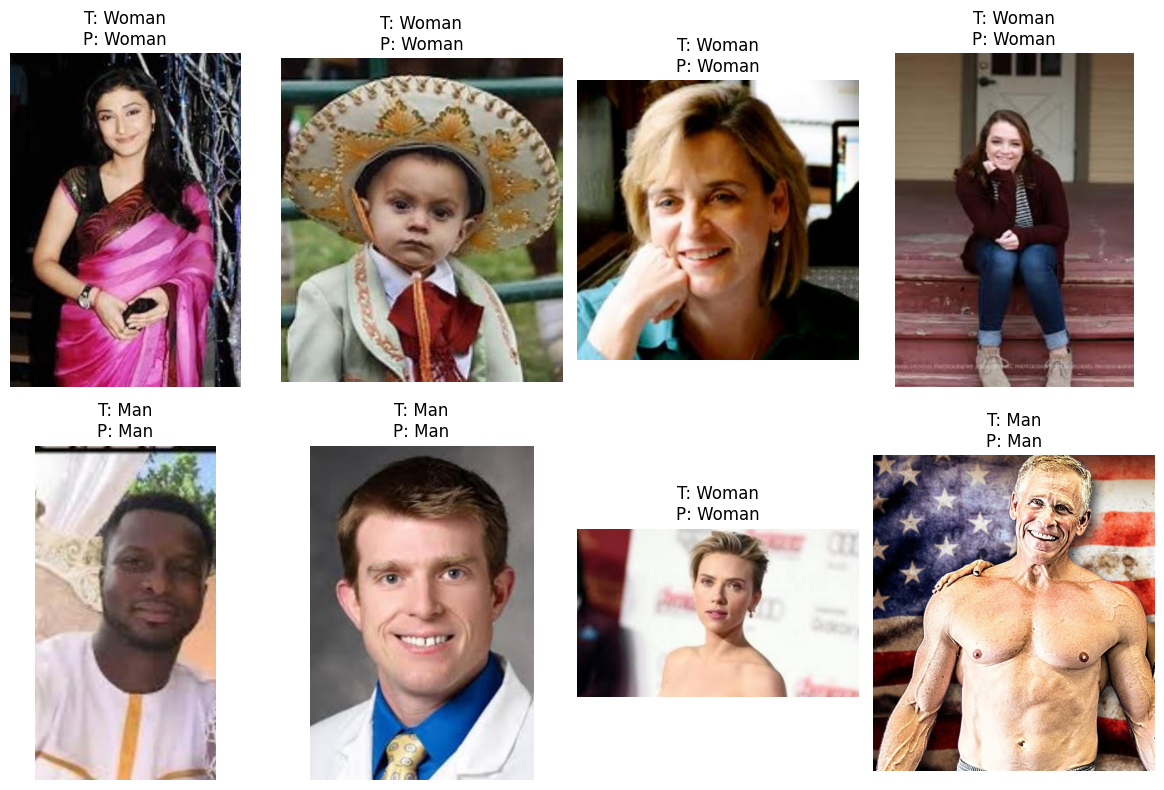

In [120]:
import random
import matplotlib.pyplot as plt

model.eval()
samples = random.sample(test_data, 8)

plt.figure(figsize=(12, 8))
for i, (img_path, true_label) in enumerate(samples):
    img = Image.open(img_path).convert("RGB")
    input_img = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        prob = torch.sigmoid(output).item()
        pred_label = 1 if prob > 0.5 else 0

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"T: {'Woman' if true_label==1 else 'Man'}\nP: {'Woman' if pred_label==1 else 'Man'}")
    plt.axis("off")

plt.tight_layout()
plt.show()